# PhonePE case cleaning and analysis

## Data Loading and Understanding

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [9]:
df_state_txn_users = pd.read_excel('phonepe_raw_data.xlsx',sheet_name = 'State_Txn and Users')
df_state_txn_category = pd.read_excel('phonepe_raw_data.xlsx',sheet_name = 'State_TxnSplit')
df_state_device_data = pd.read_excel('phonepe_raw_data.xlsx',sheet_name = 'State_DeviceData')
df_dist_txn_users = pd.read_excel('phonepe_raw_data.xlsx',sheet_name = 'District_Txn and Users')
df_dist_demo = pd.read_excel('phonepe_raw_data.xlsx',sheet_name = 'District Demographics')

In [10]:
null_values_state_txn_users = df_state_txn_users.isnull().sum().sum()
null_values_state_txn_category = df_state_txn_category.isnull().sum().sum()
null_values_state_device_data = df_state_device_data.isnull().sum().sum()
null_values_dist_txn_users = df_dist_txn_users.isnull().sum().sum()
null_values_dist_demo = df_dist_demo.isnull().sum().sum()
print(f"Null values in df_state_txn_users: {null_values_state_txn_users}")
print(f"Null values in df_state_txn_category: {null_values_state_txn_category}")
print(f"Null values in df_state_device_data: {null_values_state_device_data}")
print(f"Null values in df_dist_txn_users: {null_values_dist_txn_users}")
print(f"Null values in df_dist_demo: {null_values_dist_demo}")

Null values in df_state_txn_users: 0
Null values in df_state_txn_category: 0
Null values in df_state_device_data: 0
Null values in df_dist_txn_users: 0
Null values in df_dist_demo: 53


In [11]:
## Imputing null values in population and area columns

avg_population_state = df_dist_demo.groupby('State')['Population'].mean()
df_dist_demo['Population'] = df_dist_demo['Population'].fillna(df_dist_demo['State'].map(avg_population_state))
avg_area_state = df_dist_demo.groupby('State')['Area (sq km)'].mean()
df_dist_demo['Area (sq km)'] = df_dist_demo['Area (sq km)'].fillna(df_dist_demo['State'].map(avg_area_state))
df_dist_demo['Density'] = df_dist_demo['Density'].fillna(df_dist_demo['Population']/df_dist_demo['Area (sq km)'])

### 1.1: Load each dataset and display its structure Load 
#### 1.1.1 Load the State_Txn and Users dataset and display its first 5 rows.

In [12]:
df_state_txn_users.head()

,State,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
0,Andaman & Nicobar Islands,2018,1,6658,1.463176e+07,2197.621091,6740,0
1,Andaman & Nicobar Islands,2018,2,11340,2.833854e+07,2498.989022,9405,0
2,Andaman & Nicobar Islands,2018,3,16265,5.555747e+07,3415.768284,12149,0
3,Andaman & Nicobar Islands,2018,4,23758,9.054834e+07,3811.277720,15222,0
4,Andaman & Nicobar Islands,2019,1,30486,1.022997e+08,3355.630147,18596,0


#### 1.1.2 Load the State_TxnSplit dataset and display its bottom 10 rows.

In [13]:
df_state_txn_category.tail(10)

,State,Year,Quarter,Transaction Type,Transactions,Amount (INR),ATV (INR)
2504,West Bengal,2021,1,Peer-to-peer payments,53869075,2.022402e+11,3754.292226
2505,West Bengal,2021,1,Merchant payments,37143701,2.891834e+10,778.553104
2506,West Bengal,2021,1,Recharge & bill payments,26673733,1.133967e+10,425.124820
2507,West Bengal,2021,1,Financial Services,166727,1.754458e+08,1052.293941
2508,West Bengal,2021,1,Others,400816,2.635025e+08,657.415236
2509,West Bengal,2021,2,Peer-to-peer payments,64661051,2.308123e+11,3569.572026
2510,West Bengal,2021,2,Merchant payments,41696787,3.478787e+10,834.305703
2511,West Bengal,2021,2,Recharge & bill payments,34799709,1.333145e+10,383.090958
2512,West Bengal,2021,2,Financial Services,190537,1.864665e+08,978.636630
2513,West Bengal,2021,2,Others,549353,3.167447e+08,576.577748


#### 1.1.3 Load the State_DeviceData dataset and display 10 rows from the middle of the dataset.

In [14]:
total_rows = len(df_state_device_data)
start = (total_rows//2) - 5
middle_10 = df_state_device_data[start : start+10]
print(middle_10)

            State  Year  Quarter     Brand  Registered Users  Percentage
2767       Ladakh  2021        2   OnePlus              1741    0.023198
2768       Ladakh  2021        2  Motorola               922    0.012285
2769       Ladakh  2021        2    Huawei               894    0.011912
2770       Ladakh  2021        2    Lenovo               490    0.006529
2771       Ladakh  2021        2    Others              2610    0.034778
2772  Lakshadweep  2018        1   Samsung               102    0.203593
2773  Lakshadweep  2018        1    Xiaomi               100    0.199601
2774  Lakshadweep  2018        1      Vivo                67    0.133733
2775  Lakshadweep  2018        1      Oppo                56    0.111776
2776  Lakshadweep  2018        1    Huawei                25    0.049900


#### 1.1.4 Load the District_Txn and Users dataset and display its first 10 rows and last 10 rows.

In [15]:
first_10 = df_dist_txn_users.head(10)
last_10 = df_dist_txn_users.tail(10)
result = pd.concat([first_10, last_10], axis=0, ignore_index=True)
print(result)

                        State  Year  Quarter                    District  \
0   Andaman & Nicobar Islands  2018        1                    Nicobars   
1   Andaman & Nicobar Islands  2018        1    North And Middle Andaman   
2   Andaman & Nicobar Islands  2018        1               South Andaman   
3   Andaman & Nicobar Islands  2018        2                    Nicobars   
4   Andaman & Nicobar Islands  2018        2    North And Middle Andaman   
5   Andaman & Nicobar Islands  2018        2               South Andaman   
6   Andaman & Nicobar Islands  2018        3                    Nicobars   
7   Andaman & Nicobar Islands  2018        3    North And Middle Andaman   
8   Andaman & Nicobar Islands  2018        3               South Andaman   
9   Andaman & Nicobar Islands  2018        4                    Nicobars   
10                West Bengal  2021        2                 Murshidabad   
11                West Bengal  2021        2                       Nadia   
12          

#### 1.1.5 Load the District Demographics dataset and display every 10th row.

In [16]:
df_dist_demo.iloc[::10]

,State,District,Headquarters,Population,Area (sq km),Density,Code,Alternate Name
0,Andhra Pradesh,Anantapur,Anantapur,4.083315e+06,19130.000000,213.00000,AP01,Anantapur
10,Andhra Pradesh,Visakhapatnam,Visakhapatnam,4.288113e+06,11161.000000,384.00000,AP10,Visakhapatnam
20,Arunachal Pradesh,Lepa Rada,Basar,7.647843e+04,4220.857143,18.11917,AR08,Lepa Rada
30,Arunachal Pradesh,Siang,Pangin,3.192000e+04,2919.000000,11.00000,AR18,Siang
40,Assam,Barpeta,Barpeta,1.693622e+06,3245.000000,520.00000,AS03,Barpeta
...,...,...,...,...,...,...,...,...
700,Chandigarh,Chandigarh,Chandigarh,1.055450e+06,114.000000,9258.00000,CH01,Chandigarh
710,Jammu & Kashmir,Jammu,Jammu,1.526406e+06,3097.000000,596.00000,JK07,Jammu
720,Jammu & Kashmir,Samba,Samba,3.186110e+05,913.000000,318.00000,JK17,Samba
730,Delhi,East Delhi,Preet Vihar,1.709346e+06,440.000000,27132.00000,DL02,East


### 1.2 Display basic statistics and data types for each dataset
#### 1.2.1 For each dataset, display the summary statistics (mean, median, std, etc.) for numerical columns.

In [17]:
df_state_txn_users.describe()

,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
count,504.000000,504.000000,5.040000e+02,5.040000e+02,504.000000,5.040000e+02,5.040000e+02
mean,2019.285714,2.357143,4.074000e+07,7.218641e+10,1998.626471,4.777501e+06,9.774471e+07
std,1.031181,1.109971,8.228714e+07,1.471172e+11,601.509159,6.644496e+06,2.042376e+08
min,2018.000000,1.000000,7.780000e+02,1.928611e+06,768.481188,5.010000e+02,0.000000e+00
25%,2018.000000,1.000000,5.925578e+05,1.171833e+09,1600.921475,1.574202e+05,0.000000e+00
50%,2019.000000,2.000000,6.217487e+06,1.057102e+10,1861.892934,1.747914e+06,2.930574e+06
75%,2020.000000,3.000000,4.363675e+07,6.978343e+10,2261.814623,7.320945e+06,8.615022e+07
max,2021.000000,4.000000,5.736165e+08,1.027958e+12,3938.733850,3.966470e+07,1.208084e+09


In [18]:
df_state_txn_category.describe()

,Year,Quarter,Transactions,Amount (INR),ATV (INR)
count,2514.000000,2514.000000,2.514000e+03,2.514000e+03,2514.000000
mean,2019.286794,2.358393,8.167446e+06,1.443978e+10,1349.927929
std,1.030807,1.109251,2.423645e+07,5.995054e+10,1534.866221
min,2018.000000,1.000000,2.000000e+00,3.439721e+01,17.198606
25%,2018.000000,1.000000,2.788075e+04,1.762412e+07,385.735827
50%,2019.000000,2.000000,2.687980e+05,1.901189e+08,720.940406
75%,2020.000000,3.000000,3.683230e+06,2.661248e+09,1352.790116
max,2021.000000,4.000000,2.795990e+08,8.721520e+11,7767.539936


In [19]:
df_state_device_data.describe()

,Year,Quarter,Registered Users,Percentage
count,5544.000000,5544.000000,5.544000e+03,5544.000000
mean,2019.285714,2.357143,4.343183e+05,0.090909
std,1.030250,1.108970,9.056069e+05,0.083095
min,2018.000000,1.000000,1.000000e+01,0.006373
25%,2018.000000,1.000000,8.055750e+03,0.021588
50%,2019.000000,2.000000,7.442250e+04,0.056914
75%,2020.000000,3.000000,3.978875e+05,0.143626
max,2021.000000,4.000000,9.764252e+06,0.478367


In [20]:
df_dist_txn_users.describe()

,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
count,10248.000000,10248.000000,1.024800e+04,1.024800e+04,10248.000000,1.024800e+04,1.024800e+04
mean,2019.285714,2.357143,2.003607e+06,3.542311e+09,1909.051113,2.349591e+05,4.807117e+06
std,1.030208,1.108924,9.613466e+06,1.473154e+10,602.009256,4.605978e+05,1.562541e+07
min,2018.000000,1.000000,0.000000e+00,0.000000e+00,0.000000,2.200000e+01,0.000000e+00
25%,2018.000000,1.000000,1.031418e+05,1.756668e+08,1554.341504,3.619550e+04,0.000000e+00
50%,2019.000000,2.000000,3.763065e+05,6.784562e+08,1863.013728,1.067640e+05,6.403025e+05
75%,2020.000000,3.000000,1.272815e+06,2.377256e+09,2202.970546,2.573165e+05,4.346320e+06
max,2021.000000,4.000000,3.487128e+08,4.444224e+11,11209.980550,1.060461e+07,5.544197e+08


In [21]:
df_dist_demo.describe()

,Population,Area (sq km),Density
count,7.440000e+02,744.000000,744.000000
mean,1.677919e+06,4459.247196,889.184922
std,1.449859e+06,4209.840419,2971.782976
min,7.948000e+03,9.000000,1.000000
25%,6.592048e+05,2194.730769,200.000000
50%,1.331870e+06,3428.000000,356.000000
75%,2.294452e+06,5440.000000,688.000000
max,1.008285e+07,45652.000000,36155.000000


#### 1.2.2 Display the data types of each column in each dataset.

In [22]:
df_state_txn_users.dtypes

State                object
Year                  int64
Quarter               int64
Transactions          int64
Amount (INR)        float64
ATV (INR)           float64
Registered Users      int64
App Opens             int64
dtype: object

In [23]:
df_state_txn_category.dtypes

State                object
Year                  int64
Quarter               int64
Transaction Type     object
Transactions          int64
Amount (INR)        float64
ATV (INR)           float64
dtype: object

In [24]:
df_state_device_data.dtypes

State                object
Year                  int64
Quarter               int64
Brand                object
Registered Users      int64
Percentage          float64
dtype: object

In [25]:
df_dist_txn_users.dtypes

State                object
Year                  int64
Quarter               int64
District             object
Code                 object
Transactions          int64
Amount (INR)        float64
ATV (INR)           float64
Registered Users      int64
App Opens             int64
dtype: object

In [26]:
df_dist_demo.dtypes

State              object
District           object
Headquarters       object
Population        float64
Area (sq km)      float64
Density           float64
Code               object
Alternate Name     object
dtype: object

### 1.4: Create a summary
#### 1.4.1 Calculate the total number of states and the total number of districts.

In [27]:
states = df_dist_demo['State'].nunique()
districts = df_dist_demo['District'].nunique()
print(f"The total number of states are {states} and the total number of districts are {districts}")

The total number of states are 36 and the total number of districts are 738


#### 1.4.2 Identify the state with the highest number of districts.

In [28]:
state_name = df_dist_demo['State'].value_counts().idxmax()

print(f"The state with the highest number of districts is {state_name}")

The state with the highest number of districts is Uttar Pradesh


## Exploratory Data Analysis (EDA)

### 2.1: Analyze transaction trends over the years for each state
#### 2.1.1 Calculate the total number of transactions and total transaction amount for each state over the years. Display the results in a tabular format.

In [29]:
df_state_txn_users.groupby(['State', 'Year'])[['Transactions','Amount (INR)']].sum().reset_index()

,State,Year,Transactions,Amount (INR)
0,Andaman & Nicobar Islands,2018,58021,1.890761e+08
1,Andaman & Nicobar Islands,2019,133104,4.734648e+08
2,Andaman & Nicobar Islands,2020,446274,1.296423e+09
3,Andaman & Nicobar Islands,2021,586166,1.682854e+09
4,Andhra Pradesh,2018,77779112,1.220720e+11
...,...,...,...,...
139,Uttarakhand,2021,44608834,7.727901e+10
140,West Bengal,2018,120011635,1.115887e+11
141,West Bengal,2019,257900590,2.660145e+11
142,West Bengal,2020,304222327,5.527316e+11


#### 2.1.2 Identify the top 5 states with the highest transaction volumes and the top 5 states with the lowest transaction volumes. Display the results.

In [30]:
top5 = df_state_txn_users.groupby(['State'])['Transactions'].sum().sort_values(ascending = False).head(5)
bottom5 = df_state_txn_users.groupby(['State'])['Transactions'].sum().sort_values(ascending = False).tail(5)
pd.concat([top5, bottom5])


State
Karnataka                    2981044533
Maharashtra                  2833670154
Telangana                    2347430243
Andhra Pradesh               1781091169
Rajasthan                    1382918930
Meghalaya                       5648913
Mizoram                         2162776
Ladakh                          1880109
Andaman & Nicobar Islands       1223565
Lakshadweep                       71610
Name: Transactions, dtype: int64

### 2.2: Identify the most common transaction types in each state and quarter  
#### 2.2.1 For each state and quarter, determine the most frequent transaction type. Display the results in a tabular format.

In [31]:
grp_txn = df_state_txn_category.groupby(['State','Quarter','Transaction Type'],as_index = False)['Transactions'].sum()
max_txn = grp_txn.loc[grp_txn.groupby(['State','Quarter'])['Transactions'].idxmax()].reset_index(drop=True)
max_txn

,State,Quarter,Transaction Type,Transactions
0,Andaman & Nicobar Islands,1,Peer-to-peer payments,138772
1,Andaman & Nicobar Islands,2,Recharge & bill payments,180447
2,Andaman & Nicobar Islands,3,Recharge & bill payments,84165
3,Andaman & Nicobar Islands,4,Peer-to-peer payments,110018
4,Andhra Pradesh,1,Peer-to-peer payments,255236515
...,...,...,...,...
139,Uttarakhand,4,Peer-to-peer payments,11515030
140,West Bengal,1,Peer-to-peer payments,114083760
141,West Bengal,2,Peer-to-peer payments,118087640
142,West Bengal,3,Peer-to-peer payments,100961691


### 2.3: Determine the device brand with the highest number of registered users in each state
#### 2.3.1 Identify the device brand with the highest number of registered users in each state. Display the results in a tabular format.

In [56]:
max_year =df_state_device_data['Year'].max()
max_quarter = df_state_device_data[df_state_device_data['Year'] == max_year]['Quarter'].max()
filtered_data = df_state_device_data[(df_state_device_data['Year'] == max_year) & (df_state_device_data['Quarter'] == max_quarter)]
max_state_device_latest = filtered_data.loc[filtered_data.groupby('State')['Registered Users'].idxmax()].reset_index(drop=True)
max_state_device_latest


,State,Year,Quarter,Brand,Registered Users,Percentage
0,Andaman & Nicobar Islands,2021,2,Vivo,15056,0.242467
1,Andhra Pradesh,2021,2,Xiaomi,4937684,0.251654
2,Arunachal Pradesh,2021,2,Vivo,63439,0.234463
3,Assam,2021,2,Xiaomi,909274,0.251385
4,Bihar,2021,2,Xiaomi,4268361,0.285087
5,Chandigarh,2021,2,Xiaomi,101761,0.226855
6,Chhattisgarh,2021,2,Vivo,1169224,0.241722
7,Dadra & Nagar Haveli and Daman & Diu,2021,2,Vivo,87001,0.252181
8,Delhi,2021,2,Xiaomi,2731995,0.244306
9,Goa,2021,2,Xiaomi,152107,0.249722


### 2.4: Create a list of the top district per state based on population 
#### 2.4.1 For each state, identify the district with the highest population. Display the results in a tabular format.

In [33]:
df2 = df_dist_demo.loc[df_dist_demo.groupby("State")['Population'].idxmax(),['State','District','Population']].reset_index()

df2

,index,State,District,Population
0,699,Andaman & Nicobar Islands,South Andaman,238142.0
1,2,Andhra Pradesh,East Godavari,5151549.0
2,28,Arunachal Pradesh,Papum Pare,176385.0
3,64,Assam,Nagaon,2826006.0
4,97,Bihar,Patna,5772804.0
5,700,Chandigarh,Chandigarh,1055450.0
6,133,Chhattisgarh,Raipur,2160876.0
7,703,Dadra & Nagar Haveli and Daman & Diu,Dadra and Nagar Haveli,343709.0
8,734,Delhi,North West Delhi,3656539.0
9,138,Goa,North Goa,817761.0


#### 2.4.2 Create a column chart depicting the district with the highest population for each state. 

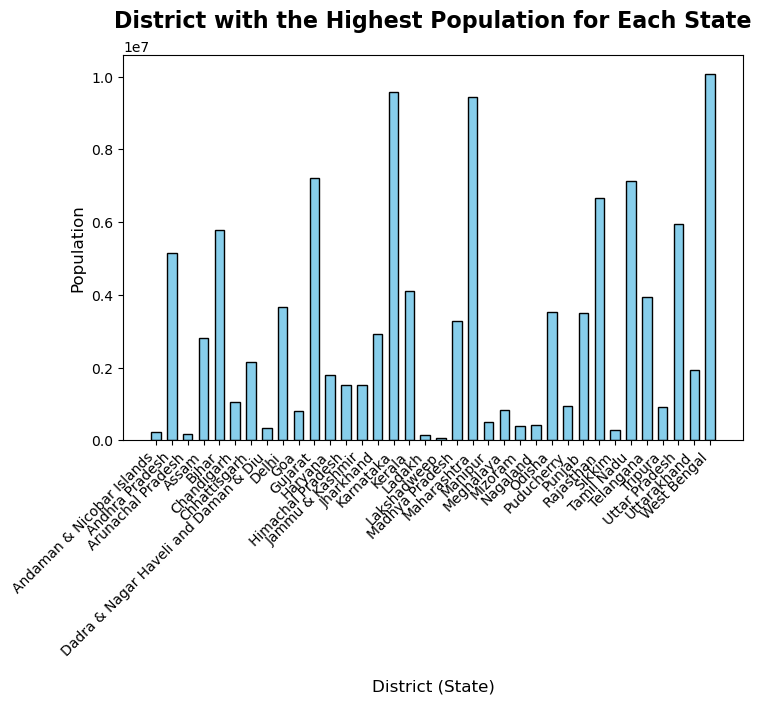

In [34]:
plt.figure(figsize=(8, 5))

plt.bar(df2['State'], df2['Population'], color='skyblue', edgecolor='black', width=0.6)

plt.title('District with the Highest Population for Each State', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('District (State)', fontsize=12, labelpad=15)
plt.ylabel('Population', fontsize=12)

plt.xticks(rotation=45, ha='right', fontsize=10)

plt.show()

### 2.5: Calculate the average transaction value (ATV) for each state
#### 2.5.1 Compute the average transaction value for each state. Display the results in a tabular format.

In [35]:
ATV = df_state_txn_users.groupby("State", as_index = False)["ATV (INR)"].mean()

ATV

,State,ATV (INR)
0,Andaman & Nicobar Islands,3159.266422
1,Andhra Pradesh,1933.668894
2,Arunachal Pradesh,2638.323985
3,Assam,2008.495656
4,Bihar,2023.316978
5,Chandigarh,2113.797075
6,Chhattisgarh,1650.818617
7,Dadra & Nagar Haveli and Daman & Diu,1487.395599
8,Delhi,1589.839307
9,Goa,1895.258549


#### 2.5.2 Identify the top 5 states with the highest ATV and the top 5 states with the lowest ATV. Display the results.

In [36]:
Top5 = ATV.sort_values(by='ATV (INR)', ascending = False).head(5)
Bottom5 = ATV.sort_values(by='ATV (INR)', ascending = False).tail(5)
pd.concat([Top5, Bottom5]).reset_index(drop = True)

,State,ATV (INR)
0,Ladakh,3408.222984
1,Andaman & Nicobar Islands,3159.266422
2,Mizoram,2927.517802
3,Lakshadweep,2776.118701
4,Arunachal Pradesh,2638.323985
5,Karnataka,1517.392249
6,Maharashtra,1516.361820
7,Dadra & Nagar Haveli and Daman & Diu,1487.395599
8,Odisha,1428.137367
9,West Bengal,1373.600590


### 2.6: Analyze app usage trends
#### 2.6.1 Calculate the total number of app opens over the years and quarters for each state. Display the results in a tabular format.

In [37]:
sum_app = df_state_txn_users.groupby(['State', 'Year', 'Quarter'], as_index=False )["App Opens"].sum()

sum_app

,State,Year,Quarter,App Opens
0,Andaman & Nicobar Islands,2018,1,0
1,Andaman & Nicobar Islands,2018,2,0
2,Andaman & Nicobar Islands,2018,3,0
3,Andaman & Nicobar Islands,2018,4,0
4,Andaman & Nicobar Islands,2019,1,0
...,...,...,...,...
499,West Bengal,2020,2,198589332
500,West Bengal,2020,3,246554831
501,West Bengal,2020,4,291721919
502,West Bengal,2021,1,316832674


#### 2.6.2 Identify trends in app usage by creating a line plot showing the number of app opens over time for a selected state.

In [38]:
selected_state = input("Enter the name of the state you want to analyze: ").strip().title()
if selected_state in sum_app['State'].values:
    state_line = sum_app[sum_app['State'] == selected_state].copy()
    state_line['Time Period'] = state_line['Year'].astype(str) + '-Q' + state_line['Quarter'].astype(str)


    plt.figure(figsize=(15,10))
    plt.plot(state_line['Time Period'],state_line['App Opens'], color = "blue")
    plt.xlabel("Year and Quarter")
    plt.ylabel("Total App Opens")
    plt.show()
else:
    print(f"State {selected_state} not in database. Please check again")

Enter the name of the state you want to analyze:  mahashtra


State Mahashtra not in database. Please check again


### 2.7: Distribution of transaction types
#### 2.7.1 Create a bar chart showing the distribution of different transaction types for each state for the most recent quarter in the dataset.

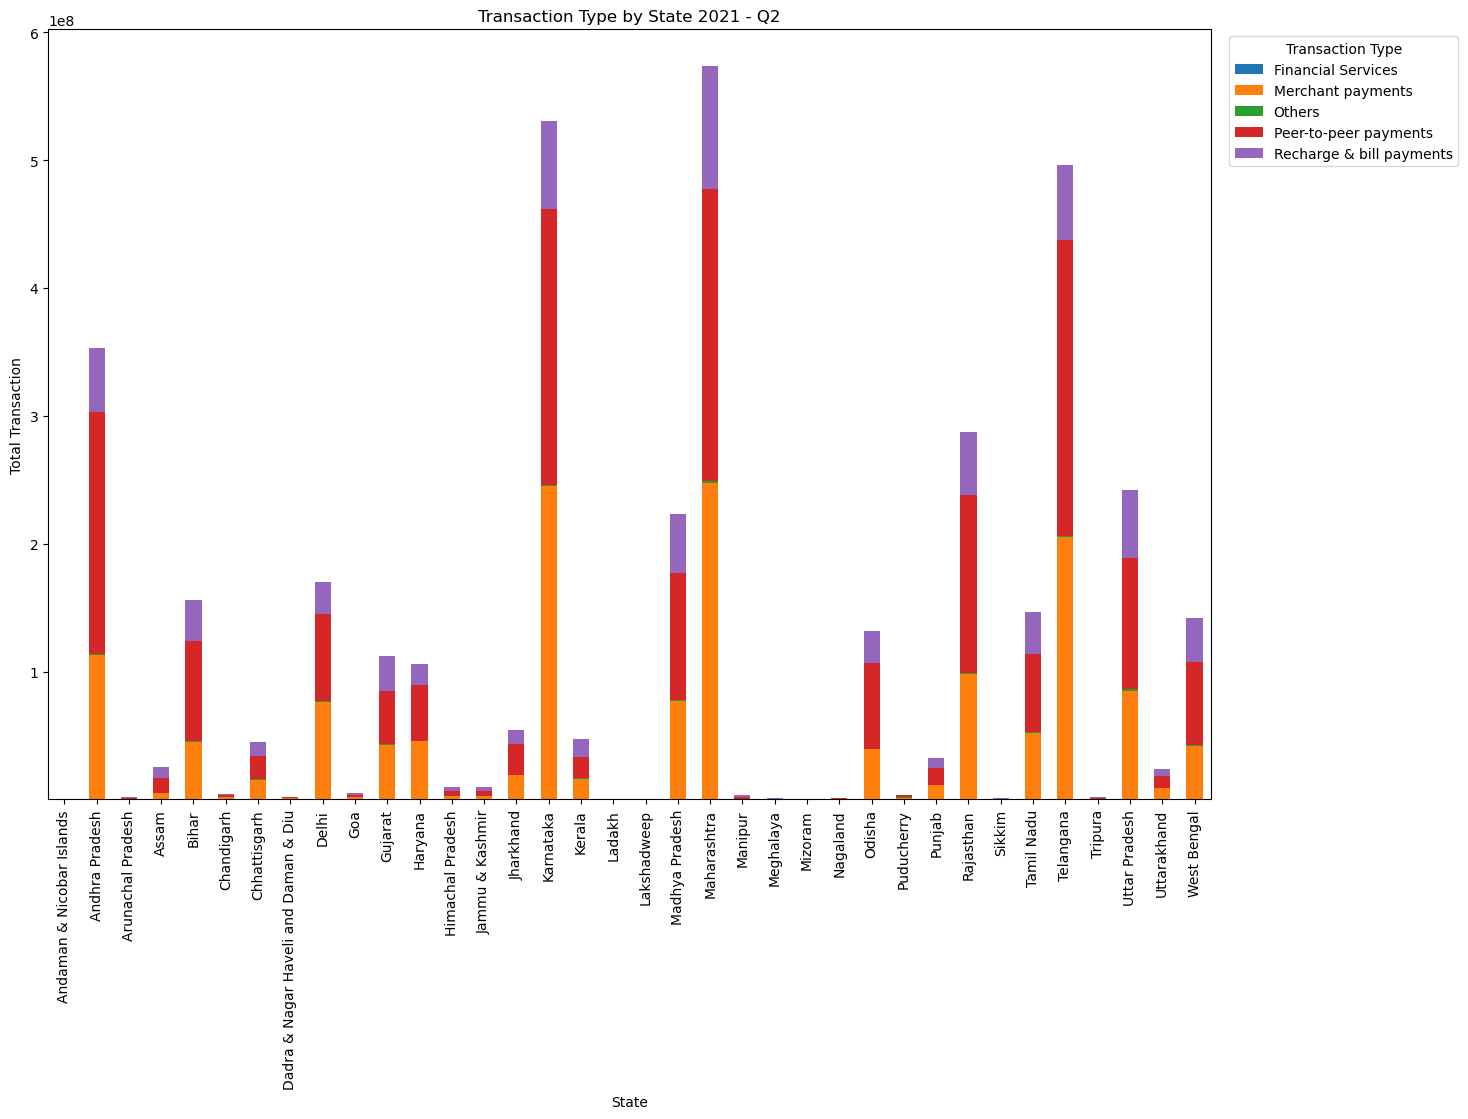

In [39]:
max_year =df_state_txn_category['Year'].max()
max_quarter = df_state_txn_category[df_state_txn_category['Year'] == max_year]['Quarter'].max()
filtered_data = df_state_txn_category[(df_state_txn_category['Year'] == max_year) & (df_state_txn_category['Quarter'] == max_quarter)]
pivot_data = filtered_data.pivot_table(index = 'State',columns = 'Transaction Type', values='Transactions',aggfunc='sum').fillna(0)
pivot_data.plot(kind = 'bar',stacked = True,figsize =(15,10))
plt.title(f"Transaction Type by State {max_year} - Q{max_quarter}")
plt.xlabel('State')
plt.ylabel('Total Transaction')
plt.legend(title='Transaction Type', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.show()

## Data Quality Checks

### 3.1: Ensure data consistency across state and district levels

In [40]:
df_state = df_state_txn_users.groupby('State')[['Transactions', 'Amount (INR)', 'Registered Users']].sum()
df_dist = df_dist_txn_users.groupby('State')[['Transactions', 'Amount (INR)', 'Registered Users']].sum()

df_state.head()
df_dist.head()

merged_df = pd.merge(df_state, df_dist, how = 'inner', on = 'State', suffixes =('- s','- d'))

merged_df['Delta Transactions'] = abs(merged_df['Transactions- s'] - merged_df['Transactions- d'])
merged_df['Delta Amount (INR)'] = round(abs(merged_df['Amount (INR)- s'] - merged_df['Amount (INR)- d']),0)
merged_df['Delta Registered Users'] = abs(merged_df['Registered Users- s'] - merged_df['Registered Users- d'])
merged_df
#merged_df[['Delta Transactions', 'Delta Amount (INR)', 'Delta Registered Users']]

,Transactions- s,Amount (INR)- s,Registered Users- s,Transactions- d,Amount (INR)- d,Registered Users- d,Delta Transactions,Delta Amount (INR),Delta Registered Users
State,,,,,,,,,
Andaman & Nicobar Islands,1223565,3.641818e+09,408396,1223565,3.641818e+09,408396,0,0.000000e+00,0
Andhra Pradesh,1781091169,3.940637e+12,158007957,1781091169,3.860292e+12,158007957,0,8.034485e+10,0
Arunachal Pradesh,8043799,2.225183e+10,1862214,8043799,2.225183e+10,1862214,0,0.000000e+00,0
Assam,123577981,2.814087e+11,26860751,123577981,2.814087e+11,26860751,0,0.000000e+00,0
Bihar,713643889,1.639579e+12,115284760,713643889,1.639579e+12,115284760,0,0.000000e+00,0
Chandigarh,25516542,5.371208e+10,3801466,25516542,5.371208e+10,3801466,0,0.000000e+00,0
Chhattisgarh,241908549,4.156353e+11,37448388,241908549,4.156353e+11,37448388,0,0.000000e+00,0
Dadra & Nagar Haveli and Daman & Diu,12462185,1.865878e+10,2701112,12462185,1.865878e+10,2701112,0,0.000000e+00,0
Delhi,1011031124,1.649942e+12,95374654,1011031124,1.649942e+12,95374654,0,0.000000e+00,0


## Data Merging and Advanced Analysis

### 4.1: Ratio of users to population by state
#### 4.1.1 Merge the State_Txn and Users dataset with the District Demographics dataset to calculate the ratio of registered users to the population for each state. Display the results in a tabular format.

In [41]:
max_year =df_state_txn_users['Year'].max()
max_quarter = df_state_txn_users[df_state_txn_users['Year'] == max_year]['Quarter'].max()
state_data = df_state_txn_users[(df_state_txn_users['Year'] == max_year) & (df_state_txn_users['Quarter'] == max_quarter)]

registered_data = state_data[['State','Registered Users']]

population_data = df_dist_demo.groupby('State', as_index = False)['Population'].sum()

merged_df = pd.merge(registered_data, population_data, on = 'State', how = 'inner', suffixes =('- s','- d'))

merged_df["Ratio"] = merged_df['Registered Users']/merged_df['Population']

merged_df

,State,Registered Users,Population,Ratio
0,Andaman & Nicobar Islands,62095,3.805810e+05,0.163158
1,Andhra Pradesh,19620905,4.937878e+07,0.397355
2,Arunachal Pradesh,270572,1.911961e+06,0.141515
3,Assam,3617056,3.446138e+07,0.104960
4,Bihar,14972134,1.038180e+08,0.144215
5,Chandigarh,448572,1.055450e+06,0.425005
6,Chhattisgarh,4837055,2.586796e+07,0.186990
7,Dadra & Nagar Haveli and Daman & Diu,344994,5.869560e+05,0.587768
8,Delhi,11182699,2.051859e+07,0.545003
9,Goa,609106,1.457723e+06,0.417848


#### 4.1.2 Create a column chart depicting the ratio of users to population by state.

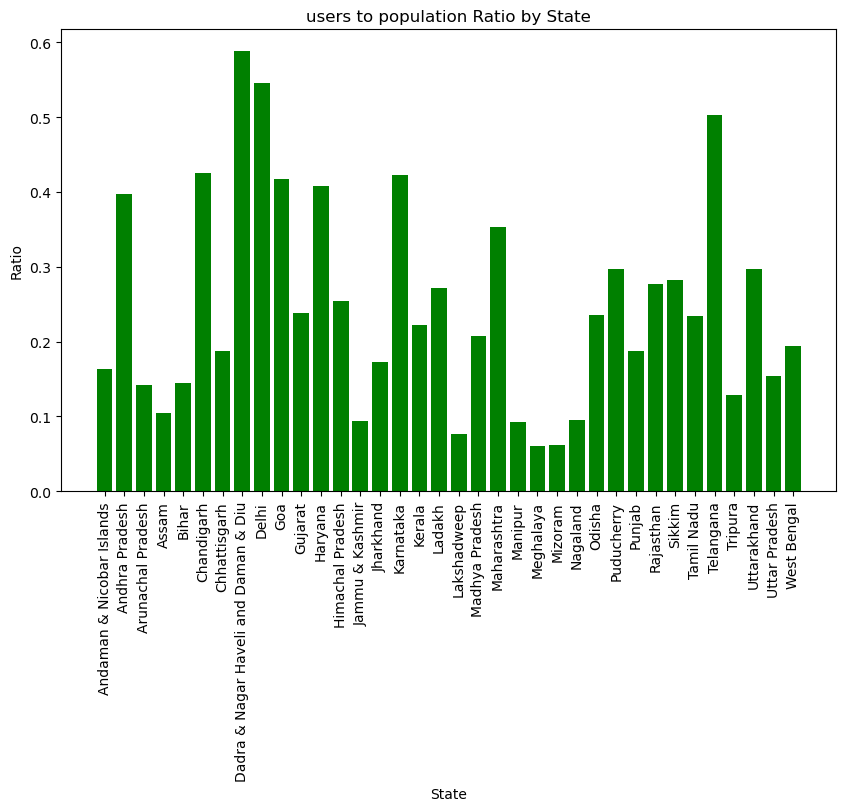

In [42]:
plt.figure(figsize=(10, 6))
plt.bar(merged_df['State'], merged_df['Ratio'], color = "Green")
plt.title('users to population Ratio by State')
plt.xlabel('State')
plt.ylabel('Ratio')
plt.xticks(rotation=90)
plt.show()


### 4.2: Correlate population density with transaction volume.
### 4.2.1 Merge the District_Txn and Users dataset with the District Demographics dataset.

In [43]:
max_year =df_dist_txn_users['Year'].max()
max_quarter = df_dist_txn_users[df_dist_txn_users['Year'] == max_year]['Quarter'].max()
district_data = df_dist_txn_users[(df_dist_txn_users['Year'] == max_year) & (df_dist_txn_users['Quarter'] == max_quarter)]

transaction_vol = district_data[["Code","State","District","Transactions"]]

dis_density = df_dist_demo[["Code", "District", "Density"]]

merged = pd.merge(transaction_vol, dis_density, on = "Code", how = "inner", suffixes =('- t','- d'))

merged


,Code,State,District- t,Transactions,District- d,Density
0,AN01,Andaman & Nicobar Islands,Nicobars,15307,Nicobar,20.0
1,AN02,Andaman & Nicobar Islands,North And Middle Andaman,39200,North and Middle Andaman,28.0
2,AN03,Andaman & Nicobar Islands,South Andaman,286907,South Andaman,89.0
3,AP01,Andhra Pradesh,Anantapur,25123346,Anantapur,213.0
4,AP02,Andhra Pradesh,Chittoor,34344902,Chittoor,275.0
...,...,...,...,...,...,...
727,WB19,West Bengal,Purba Bardhaman,3920729,Purba Bardhaman,890.0
728,WB20,West Bengal,Purba Medinipur,6418522,Purba Medinipur,1076.0
729,WB21,West Bengal,Purulia,1895981,Purulia,468.0
730,WB22,West Bengal,South Twenty Four Parganas,6661813,South 24 Parganas,819.0


#### 4.2.2 Calculate the correlation between population density and transaction volume.

In [44]:
correln = round(merged["Density"].corr(merged["Transactions"]),2)

print(f"the correlation coefficient between population density and transaction volume is {correln}")

the correlation coefficient between population density and transaction volume is 0.24


#### 4.2.3 Create a scatter plot to visualize the correlation between population density and transaction volume.


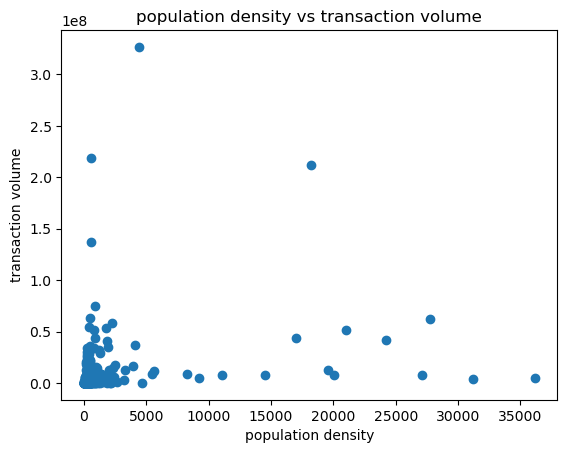

In [45]:
plt.scatter(merged['Density'], merged["Transactions"])

# 3. Add titles and labels for context
plt.title("population density vs transaction volume")
plt.xlabel("population density")
plt.ylabel("transaction volume")

# 4. Display the graph
plt.show()

### 4.3: Average transaction amount per user 
#### 4.3.1 Merge relevant datasets to calculate the average transaction amount per user for each state. Display the results in a tabular format.

In [46]:
avg_table = df_state_txn_users.groupby('State', as_index=False)[['Amount (INR)','Registered Users']].sum()

avg_table["Avg Transaction amount per user"] = round(avg_table['Amount (INR)']/avg_table['Registered Users'],2)

avg_table

,State,Amount (INR),Registered Users,Avg Transaction amount per user
0,Andaman & Nicobar Islands,3.641818e+09,408396,8917.37
1,Andhra Pradesh,3.940637e+12,158007957,24939.48
2,Arunachal Pradesh,2.225183e+10,1862214,11949.13
3,Assam,2.814087e+11,26860751,10476.58
4,Bihar,1.639579e+12,115284760,14221.99
5,Chandigarh,5.371208e+10,3801466,14129.31
6,Chhattisgarh,4.156353e+11,37448388,11098.88
7,Dadra & Nagar Haveli and Daman & Diu,1.865878e+10,2701112,6907.82
8,Delhi,1.649942e+12,95374654,17299.59
9,Goa,4.427187e+10,4755320,9309.97


#### 4.3.2 Identify the top 5 states with the highest average transaction amount per user and the top 5 states with the lowest average transaction amount per user. Display the results.

In [47]:
top5 = avg_table.sort_values(by = 'Avg Transaction amount per user', ascending = False).head()
bottom5 = avg_table.sort_values(by = 'Avg Transaction amount per user', ascending = False).tail()

pd.concat([top5,bottom5]).reset_index(drop = True)

,State,Amount (INR),Registered Users,Avg Transaction amount per user
0,Telangana,4.574246e+12,149224214,30653.51
1,Andhra Pradesh,3.940637e+12,158007957,24939.48
2,Karnataka,4.361396e+12,203098564,21474.28
3,Rajasthan,2.625584e+12,149770064,17530.77
4,Delhi,1.649942e+12,95374654,17299.59
5,Himachal Pradesh,9.786546e+10,13373980,7317.60
6,Kerala,3.729599e+11,51267042,7274.85
7,Dadra & Nagar Haveli and Daman & Diu,1.865878e+10,2701112,6907.82
8,Tripura,2.097051e+10,3661575,5727.18
9,Lakshadweep,1.921587e+08,34223,5614.90


### 4.4: Device brand usage ratio
#### 4.4.1 Merge the State_DeviceData dataset with the State_Txn and Users dataset.
#### 4.4.2 Calculate the ratio of users using each device brand to the total number of registered users in each state. Display the results in a tabular format.

In [48]:
merged_df = pd.merge(df_state_txn_users,df_state_device_data, on = ['State', 'Year', 'Quarter'],how = "inner",suffixes = ('_s','_d'))
merged_df['Brand_Ratio'] = (merged_df['Registered Users_d']/merged_df['Registered Users_s']).round(3)

#first way
pivot_data = merged_df.pivot_table(index='State',columns = 'Brand',values = 'Brand_Ratio', aggfunc = 'mean').fillna(0).round(4)

#second way
non_pivot_way = merged_df.groupby(['State','Brand'], as_index = False)['Brand_Ratio'].mean().round(4).head(5)

pivot_data

Brand,Apple,Asus,COOLPAD,Gionee,HMD Global,Huawei,Infinix,Lava,Lenovo,Lyf,Micromax,Motorola,OnePlus,Oppo,Others,Realme,Samsung,Tecno,Vivo,Xiaomi
State,,,,,,,,,,,,,,,,,,,,
Andaman & Nicobar Islands,0.0258,0.0000,0.00,0.0000,0.0000,0.0278,0.0000,0.0000,0.0212,0.000,0.0000,0.0264,0.0417,0.0859,0.0863,0.0524,0.1920,0.0150,0.1999,0.2415
Andhra Pradesh,0.0276,0.0000,0.00,0.0000,0.0000,0.0255,0.0000,0.0000,0.0191,0.000,0.0000,0.0332,0.0264,0.1030,0.0774,0.0743,0.2017,0.0000,0.1583,0.2537
Arunachal Pradesh,0.0221,0.0000,0.00,0.0159,0.0000,0.0112,0.0000,0.0000,0.0162,0.000,0.0000,0.0128,0.0126,0.1449,0.0728,0.0636,0.1996,0.0000,0.2044,0.2387
Assam,0.0162,0.0163,0.00,0.0170,0.0000,0.0170,0.0000,0.0000,0.0166,0.000,0.0000,0.0176,0.0000,0.1270,0.1171,0.0760,0.1554,0.0000,0.1779,0.2625
Bihar,0.0116,0.0000,0.00,0.0000,0.0080,0.0160,0.0116,0.0000,0.0161,0.000,0.0122,0.0200,0.0000,0.1150,0.0977,0.0819,0.2049,0.0100,0.1334,0.2919
Chandigarh,0.0821,0.0000,0.00,0.0000,0.0110,0.0151,0.0000,0.0000,0.0170,0.000,0.0177,0.0257,0.0316,0.1171,0.0913,0.0349,0.1993,0.0000,0.1497,0.2377
Chhattisgarh,0.0168,0.0000,0.00,0.0000,0.0000,0.0075,0.0000,0.0000,0.0125,0.000,0.0827,0.0127,0.0159,0.1051,0.0846,0.0644,0.1738,0.0000,0.1961,0.2361
Dadra & Nagar Haveli and Daman & Diu,0.0206,0.0000,0.00,0.0000,0.0000,0.0165,0.0000,0.0000,0.0208,0.000,0.0160,0.0206,0.0143,0.1164,0.0988,0.0626,0.1783,0.0120,0.2121,0.2394
Delhi,0.0577,0.0000,0.00,0.0000,0.0000,0.0179,0.0000,0.0000,0.0179,0.000,0.0000,0.0311,0.0311,0.1106,0.0976,0.0429,0.1909,0.0000,0.1479,0.2544


#### 4.4.3 Create a bar chart depicting the device brand usage ratio for each state.

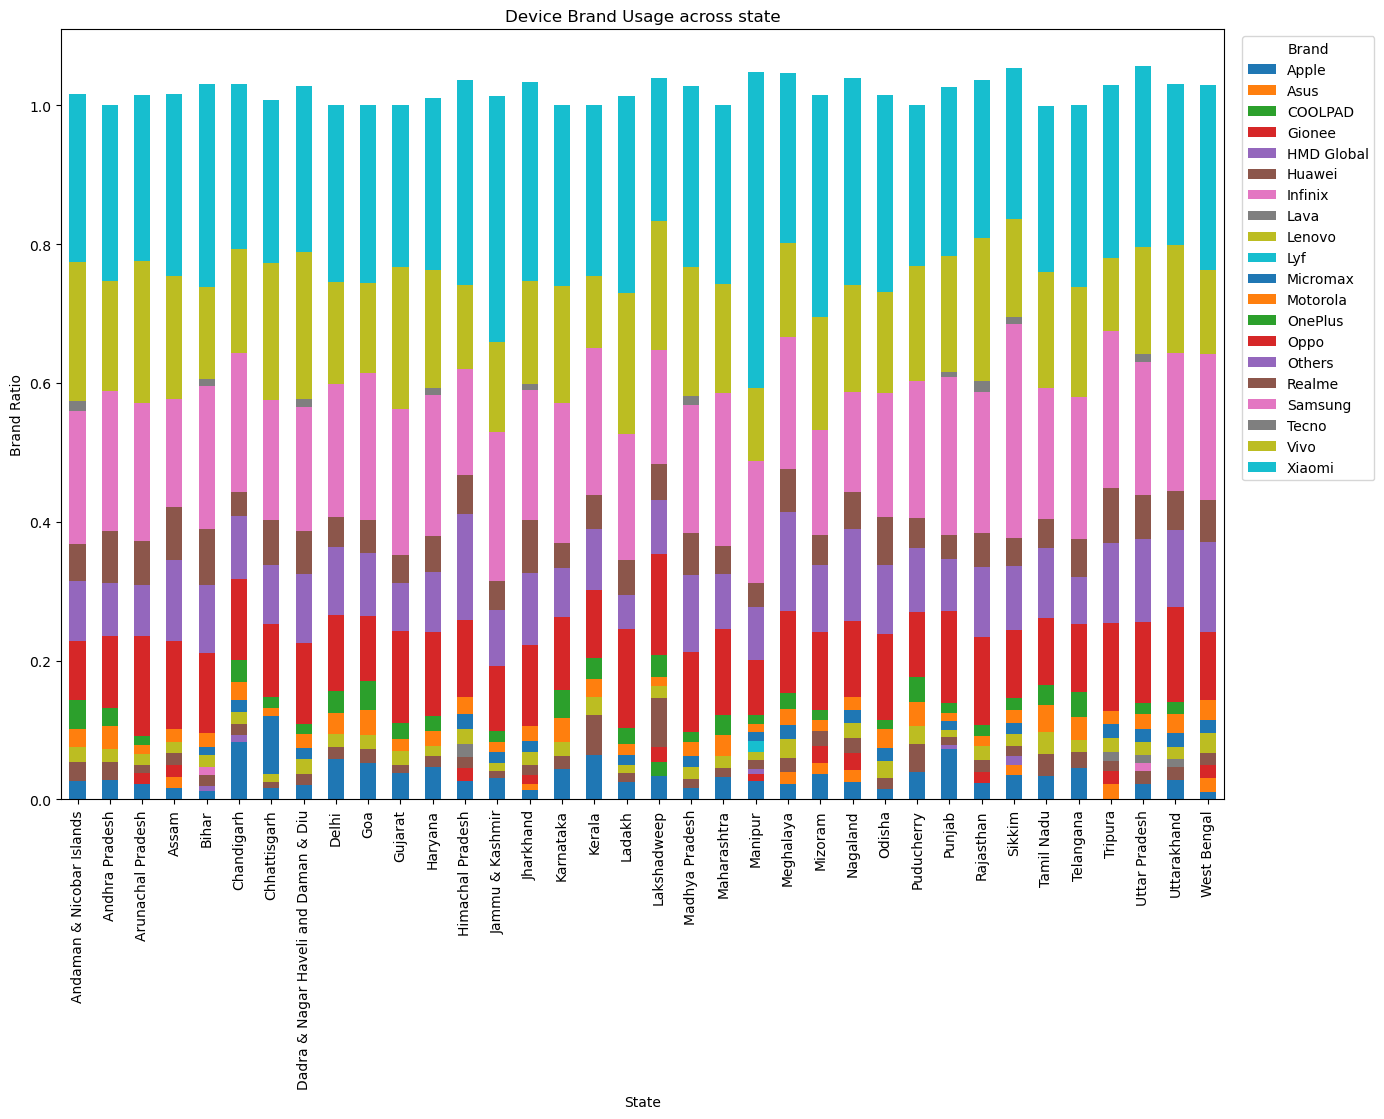

In [49]:
pivot_data.plot(kind = 'bar',stacked = True,figsize =(15,10))
plt.title("Device Brand Usage across state")
plt.xlabel('State')
plt.ylabel('Brand Ratio')
plt.legend(title='Brand', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.show()

##  Data Visualization

### 5.1: Plot the total transactions and amount over time for a selected state.
#### 5.1.1 Create a line plot showing the total number of transactions and the total transaction amount over time (years and quarters) for a selected state. 

In [50]:
summary_table = df_state_txn_users.groupby(['State', 'Year', 'Quarter'], as_index=False )[["Transactions", "Amount (INR)"]].sum()

summary_table

,State,Year,Quarter,Transactions,Amount (INR)
0,Andaman & Nicobar Islands,2018,1,6658,1.463176e+07
1,Andaman & Nicobar Islands,2018,2,11340,2.833854e+07
2,Andaman & Nicobar Islands,2018,3,16265,5.555747e+07
3,Andaman & Nicobar Islands,2018,4,23758,9.054834e+07
4,Andaman & Nicobar Islands,2019,1,30486,1.022997e+08
...,...,...,...,...,...
499,West Bengal,2020,2,57676797,1.000994e+11
500,West Bengal,2020,3,79954504,1.568134e+11
501,West Bengal,2020,4,100340645,1.991655e+11
502,West Bengal,2021,1,118254052,2.429372e+11


Enter the name of the state you want to analyze:  Maharashtra


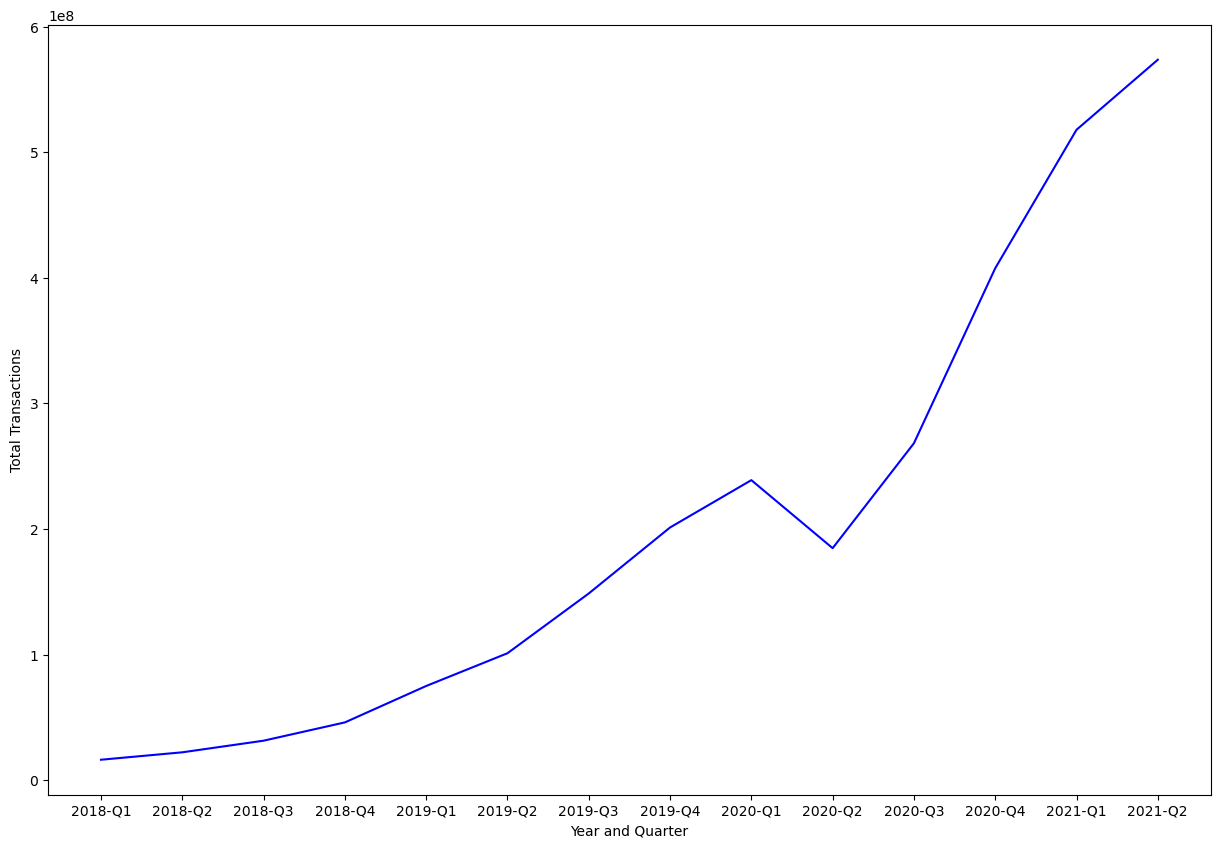

In [51]:
## Create a line plot showing the total number of transactions and the total transaction amount over time (years and quarters) for a selected state.

selected_state = input("Enter the name of the state you want to analyze: ").strip().title()
if selected_state in summary_table['State'].values:
    state_line = summary_table[summary_table['State'] == selected_state].copy()
    state_line['Time Period'] = state_line['Year'].astype(str) + '-Q' + state_line['Quarter'].astype(str)


    plt.figure(figsize=(15,10))
    plt.plot(state_line['Time Period'],state_line['Transactions'],  color = "blue")
    plt.xlabel("Year and Quarter")
    plt.ylabel("Total Transactions")
    plt.show()
else:
    print(f"State {selected_state} not in database. Please check again")

Enter the name of the state you want to analyze:  West Bengal


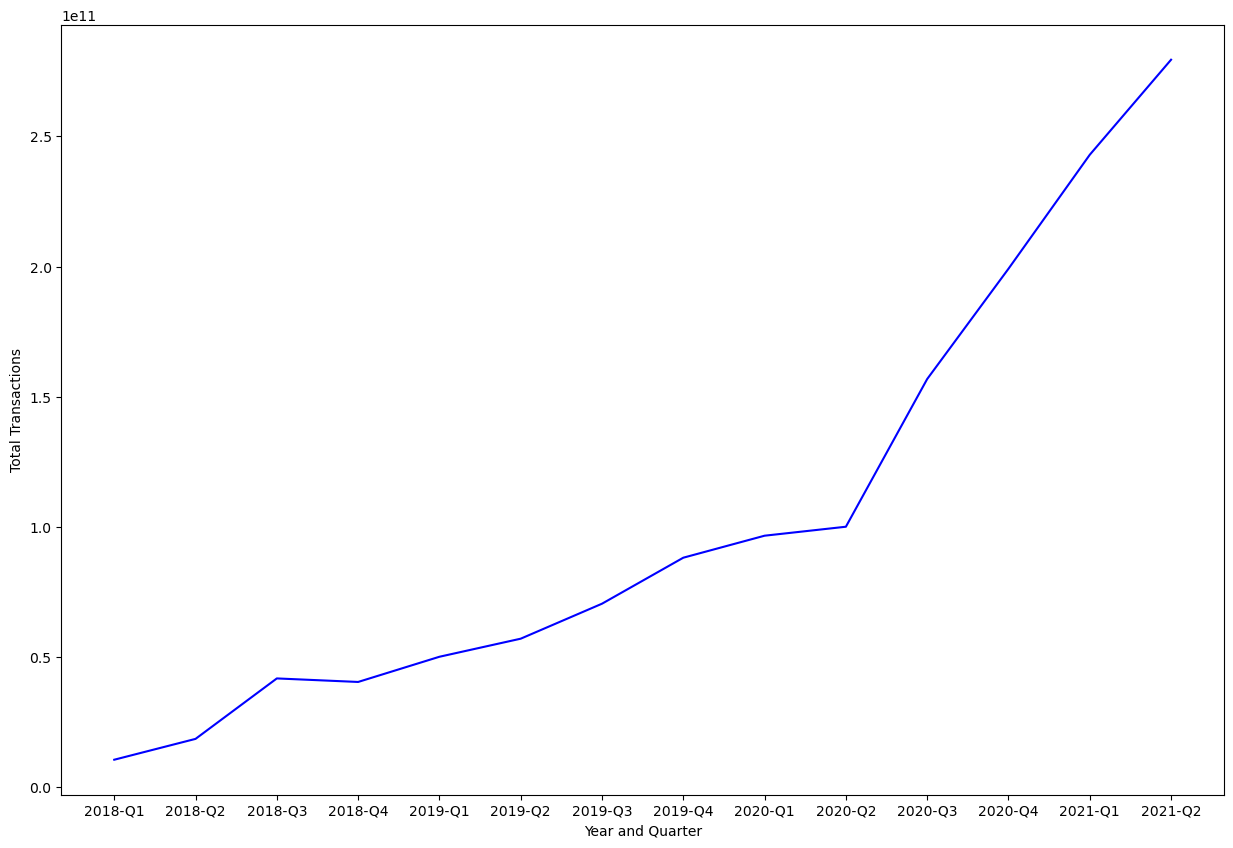

In [52]:
## Create a line plot showing the total transaction amount over time (years and quarters) for a selected state.

selected_state = input("Enter the name of the state you want to analyze: ").strip().title()
if selected_state in summary_table['State'].values:
    state_line = summary_table[summary_table['State'] == selected_state].copy()
    state_line['Time Period'] = state_line['Year'].astype(str) + '-Q' + state_line['Quarter'].astype(str)


    plt.figure(figsize=(15,10))
    plt.plot(state_line['Time Period'],state_line['Amount (INR)'],  color = "blue")
    plt.xlabel("Year and Quarter")
    plt.ylabel("Total Transactions")
    plt.show()
else:
    print(f"State {selected_state} not in database. Please check again")

### 5.2: Create a pie chart showing the distribution of transaction types for a specific quarter.
#### 5.2.1 Create a pie chart showing the distribution of different transaction types for a selected state and quarter.

In [53]:
selected_state = input("Enter the name of the state you want to analyze: ").strip().title()
selected_year = int(input("Enter the year you want to analyze (between 2018-2021: ").strip())
selected_quarter = int(input("Enter the year you want to analyze(1,2,3,4): ").strip())
filter_data = df_state_txn_category[
    (df_state_txn_category['State']==selected_state) &
    (df_state_txn_category['Year']== selected_year) &
    (df_state_txn_category['Quarter']== selected_quarter)]
if not filter_data.empty:
    pie_data = filter_data.groupby('Transaction Type')['Transactions'].sum()
    plt.figure(figsize = (7,7))
    plt.pie(pie_data,labels= pie_data.index)
    plt.title(f"Distribution of Transaction Types in {selected_state}\n(Q{selected_quarter} {selected_year})")
    plt.show()
else:
    print("Check Input again")

Enter the name of the state you want to analyze:  West Bengal
Enter the year you want to analyze (between 2018-2021:  2021
Enter the year you want to analyze(1,2,3,4):  3


Check Input again


### 5.3: Visualize the population density of districts in a selected state.

#### 5.3.1 Create a bar plot showing the population density of districts in a selected state.

Enter the name of the state you want to analyze:  West Bengal


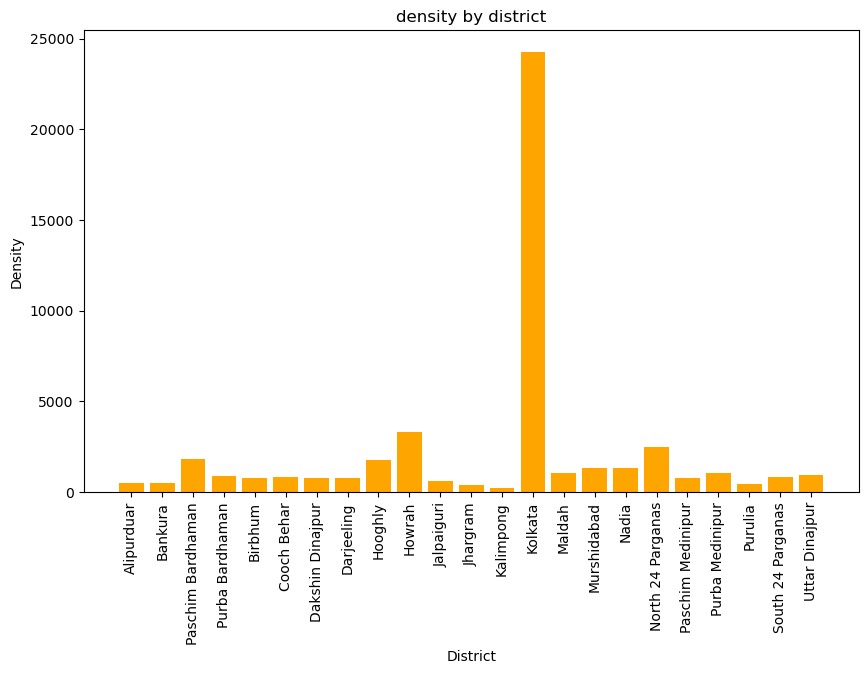

In [54]:
selected_state = input("Enter the name of the state you want to analyze: ")
if selected_state in summary_table['State'].values:
    filtered_data = df_dist_demo[df_dist_demo["State"] == selected_state]

    plt.figure(figsize=(10, 6))
    plt.bar(filtered_data['District'], filtered_data['Density'], color = "Orange")
    plt.title('density by district')
    plt.xlabel('District')
    plt.ylabel('Density')
    plt.xticks(rotation=90)
    plt.show()
else:
    print("Invalid state")
    